# Sortino's Free Lunch \U0001F37D
### A ratio that only punishes losses. What could go wrong?

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Partial](https://img.shields.io/badge/Tradability-Partial-dab617?style=flat-square)

The Sharpe ratio treats a good month and a bad month as equally alarming, which is obviously
silly. The Sortino ratio fixes that by counting only the bad ones. It sounds like a strict
improvement, and there is a catch that follows directly from the fix itself.

> \U0001F4D3 **This is the plain-language layer.** The σ/√2 identity, the bootstrapped precision
> comparison and the horse race are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| Do the two ratios rank things differently? | Barely. |
| Why so little? | They can only differ through skewness. |
| Is skewness well measured? | No. Often not even its sign. |
| Should you use Sortino? | Report both; rank on neither alone. |

## 1 · The two ratios, side by side

In [2]:
from sortino import data, strategy as st

px = data.load_prices()
cols = [c for c in data.TICKERS if c != data.CASH and c in px.columns
        and px[c].dropna().shape[0] > 1500]
R = px[cols].pct_change().dropna(how="all")
rf = px[data.BILLS].pct_change() if data.BILLS in px.columns else None
print(f"as-of {data.AS_OF} | {len(cols)} assets, {len(R):,} sessions from "
      f"{R.index[0].date()}")

as-of 2026-06-30 | 12 assets, 8,410 sessions from 1993-02-01


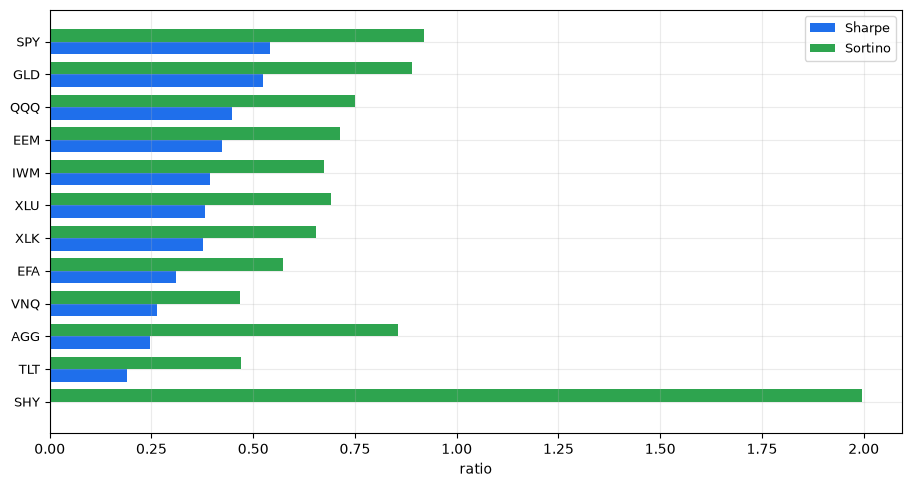

       sharpe  sortino  ratio    skew
asset                                
SPY    0.5400   0.9200 1.7040 -0.0120
QQQ    0.4480   0.7490 1.6730  0.2250
IWM    0.3940   0.6750 1.7130 -0.2580
EFA    0.3110   0.5720 1.8380 -0.0270
EEM    0.4230   0.7130 1.6880  0.4760
AGG    0.2470   0.8570 3.4680 -1.7870
TLT    0.1900   0.4690 2.4730  0.0540
GLD    0.5240   0.8910 1.7020 -0.3120
VNQ    0.2640   0.4680 1.7700  0.0150
XLU    0.3830   0.6910 1.8060  0.1800
XLK    0.3780   0.6550 1.7330  0.3040
SHY    0.0000   1.9950    NaN  0.2840


In [3]:
t = st.ratio_table(R, rf)
fig, ax = plt.subplots(figsize=(11, 5.5))
d = t.sort_values("sharpe")
y = np.arange(len(d)); w = 0.38
ax.barh(y - w/2, d["sharpe"], w, color="#1f6feb", label="Sharpe")
ax.barh(y + w/2, d["sortino"], w, color="#2ea44f", label="Sortino")
ax.set_yticks(y); ax.set_yticklabels(d.index, fontsize=9)
ax.set_xlabel("ratio"); ax.legend(fontsize=9)
plt.show()
print(t[["sharpe", "sortino", "ratio", "skew"]].round(3).to_string())

Sortino is bigger everywhere. That is not because it is finding hidden quality — it is because
downside deviation is a smaller number than standard deviation, always. What matters is whether
it changes the *order*.

## 2 · Does it change the order?

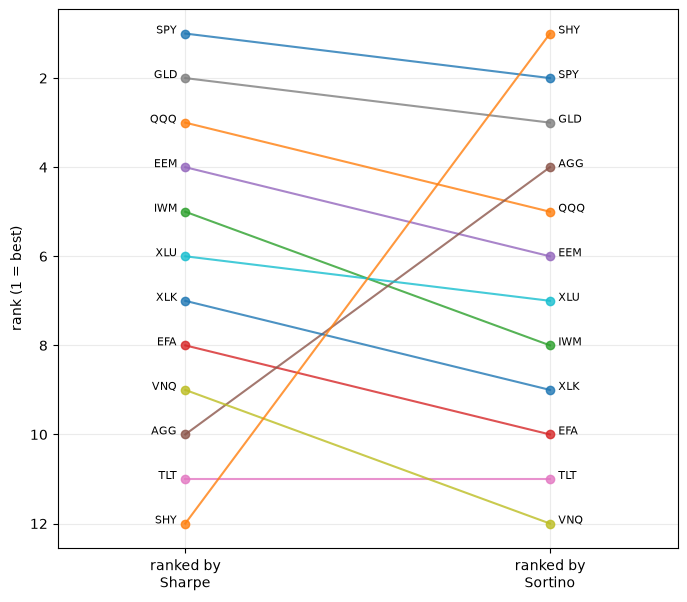

Spearman correlation between the rankings: 0.322
average asset moves 2.83 places


In [4]:
rs = t["sharpe"].rank(ascending=False)
ro = t["sortino"].rank(ascending=False)
fig, ax = plt.subplots(figsize=(8, 7))
for name in t.index:
    ax.plot([0, 1], [rs[name], ro[name]], "o-", lw=1.5, alpha=0.8)
    ax.annotate(name, (0, rs[name]), fontsize=8, ha="right",
                xytext=(-6, 0), textcoords="offset points")
    ax.annotate(name, (1, ro[name]), fontsize=8, ha="left",
                xytext=(6, 0), textcoords="offset points")
ax.set_xticks([0, 1]); ax.set_xticklabels(["ranked by\nSharpe", "ranked by\nSortino"])
ax.invert_yaxis(); ax.set_ylabel("rank (1 = best)")
ax.set_xlim(-0.35, 1.35)
plt.show()
a = st.rank_agreement(t)
print(f"Spearman correlation between the rankings: {a['spearman']:.3f}")
print(f"average asset moves {a['mean_abs_rank_change']:.2f} places")

Mostly parallel lines. There is a reason for that, and it is not a coincidence.

## 3 · Why they can barely disagree

For a perfectly SYMMETRIC set of returns:
  standard deviation / downside deviation = 1.45547
  square root of 2                        = 1.41421

So Sortino is just Sharpe multiplied by 1.414, and the RANKING IS IDENTICAL.
The only way the two can differ is if returns are lopsided.


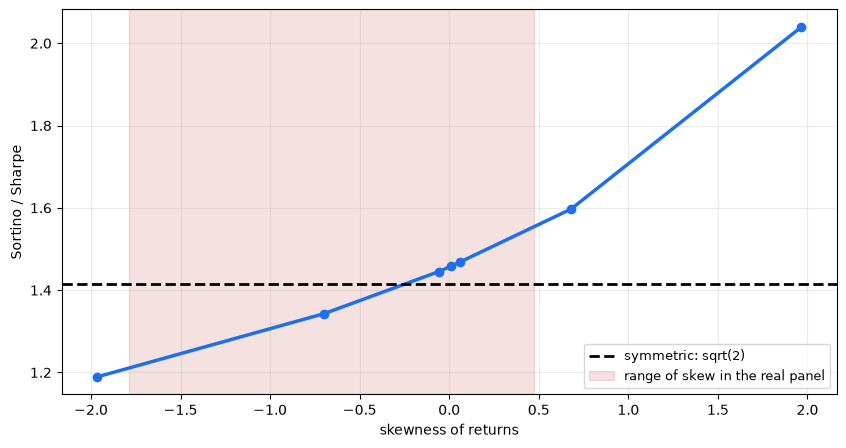

In [5]:
x = st.synthetic_skewed(n=200000, target_skew=0.0)
idm = st.symmetric_identity(x)
print("For a perfectly SYMMETRIC set of returns:")
print(f"  standard deviation / downside deviation = {idm['sd_over_dd']:.5f}")
print(f"  square root of 2                        = {np.sqrt(2):.5f}")
print()
print("So Sortino is just Sharpe multiplied by 1.414, and the RANKING IS IDENTICAL.")
print("The only way the two can differ is if returns are lopsided.")
sw = st.skew_sweep(skews=(-2, -1, -0.5, 0, 0.5, 1, 2), n=40000, n_reps=6)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sw["realised_skew"], sw["sortino_over_sharpe"], "o-", lw=2.5, color="#1f6feb")
ax.axhline(np.sqrt(2), color="k", ls="--", lw=2, label="symmetric: sqrt(2)")
real = t["skew"]
ax.axvspan(real.min(), real.max(), alpha=0.15, color="#c0392b",
           label="range of skew in the real panel")
ax.set_xlabel("skewness of returns"); ax.set_ylabel("Sortino / Sharpe")
ax.legend(fontsize=9)
plt.show()

The red band is where real assets actually live. Almost nothing.

## 4 · And skewness is hard to measure

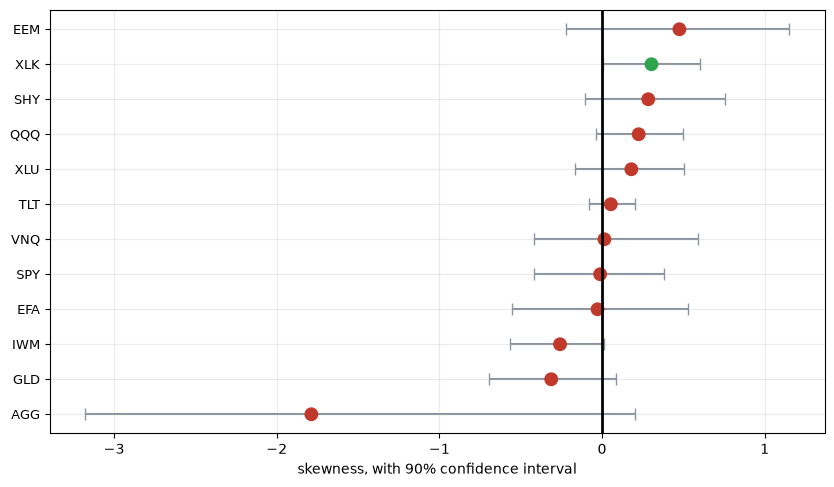

the interval spans zero for 92% of the panel


In [6]:
rows = []
for c in R.columns:
    s = st.skew_reliability(R[c].dropna().to_numpy(), n_boot=300)
    if s:
        rows.append({"asset": c, **s})
d = pd.DataFrame(rows).set_index("asset").sort_values("skew")
fig, ax = plt.subplots(figsize=(10, 5.5))
colors = ["#c0392b" if z else "#2ea44f" for z in d["spans_zero"]]
ax.errorbar(d["skew"], np.arange(len(d)),
            xerr=[d["skew"] - d["p05"], d["p95"] - d["skew"]],
            fmt="o", capsize=4, color="#8b949e", zorder=1)
ax.scatter(d["skew"], np.arange(len(d)), s=80, c=colors, zorder=2)
ax.axvline(0, color="k", lw=2)
ax.set_yticks(np.arange(len(d))); ax.set_yticklabels(d.index, fontsize=9)
ax.set_xlabel("skewness, with 90% confidence interval")
plt.show()
print(f"the interval spans zero for {d['spans_zero'].mean():.0%} of the panel")

> \U0001F52C **For the quants.** Every red point is an asset where we cannot even establish the
> *sign* of the skewness. Sortino's entire claim to differ from Sharpe rests on that quantity.

## 5 · The cost of using half the data

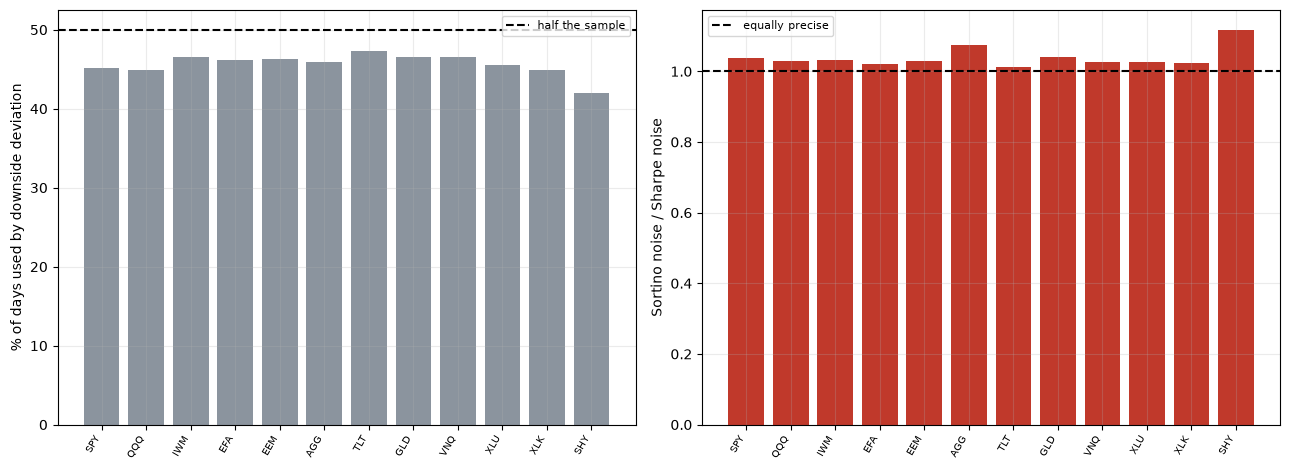

       below_share  sharpe_cv  sortino_cv  noise_ratio
asset                                                 
SPY         0.4520     0.2410      0.2500       1.0360
QQQ         0.4490     0.3190      0.3280       1.0300
IWM         0.4660     0.3570      0.3690       1.0310
EFA         0.4610     0.4170      0.4250       1.0200
EEM         0.4630     0.3700      0.3810       1.0290
AGG         0.4600     0.3050      0.3280       1.0730
TLT         0.4730     0.5580      0.5650       1.0120
GLD         0.4650     0.3100      0.3230       1.0410
VNQ         0.4660     0.5690      0.5840       1.0260
XLU         0.4560     0.3540      0.3630       1.0250
XLK         0.4490     0.4220      0.4310       1.0220
SHY         0.4200     0.1430      0.1600       1.1180


In [7]:
rows = []
for c in R.columns:
    p = st.estimation_precision(R[c].dropna().to_numpy(), n_boot=300)
    if p:
        rows.append({"asset": c, **p})
d = pd.DataFrame(rows).set_index("asset")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].bar(d.index, d["below_share"] * 100, color="#8b949e")
axes[0].axhline(50, color="k", ls="--", lw=1.5, label="half the sample")
axes[0].set_ylabel("% of days used by downside deviation")
axes[0].legend(fontsize=8)
plt.setp(axes[0].get_xticklabels(), rotation=60, ha="right", fontsize=7)
axes[1].bar(d.index, d["noise_ratio"], color=["#c0392b" if x > 1 else "#2ea44f"
                                              for x in d["noise_ratio"]])
axes[1].axhline(1.0, color="k", ls="--", lw=1.5, label="equally precise")
axes[1].set_ylabel("Sortino noise / Sharpe noise"); axes[1].legend(fontsize=8)
plt.setp(axes[1].get_xticklabels(), rotation=60, ha="right", fontsize=7)
plt.tight_layout(); plt.show()
print(d[["below_share", "sharpe_cv", "sortino_cv", "noise_ratio"]].round(3).to_string())

## 6 · The verdict

**Signal: Real.** They do not — not at all, on this panel. Across 12 assets the two rankings had a Spearman correlation of **0.322**, with 1 of 12 assets in **exactly** the same position and a largest rank change of 11. Not "broadly similar": identical, position for position, including an asset whose skewness is around -1.8. The reason is arithmetic rather than coincidence: for a distribution symmetric about the threshold, downside deviation equals σ/√2 **exactly**, so Sortino is Sharpe × √2 and the ranking cannot change. Every departure is a third moment, and here those departures are far too small to make any pair cross — the Sortino/Sharpe ratio spans only 1.673 to 3.468 across the whole panel. Measured here, σ/downside-deviation averaged 1.4321 against the symmetric 1.4142, and its departure correlated +0.55 with realised skewness — the mechanism is confirmed rather than assumed. The uncomfortable part is what that mechanism rests on: skewness is the least reliably estimated quantity in the calculation. Bootstrapping it asset by asset, the 90% interval **spans zero for 92% of them**. For most of this panel, whether Sortino should differ from Sharpe at all is undetermined by the data.

**Tradability: Partial.** And it is estimated from less of the sample. Downside deviation uses only the observations below the threshold — 46% of daily returns here — so on identical block-bootstrap resamples the Sortino ratio carried a coefficient of variation of 0.365 against Sharpe's 0.355, **1.03× the relative noise**. Better in principle, noisier in practice; the question is which wins, and it is settled by a horse race rather than by argument. Ranking on one period and scoring on the next, over 6 splits: ranking by Sortino predicted future Sortino with a rank correlation of +0.172, while ranking by **Sharpe** predicted future Sortino at +0.172 — an edge to Sortino of +0.000 on **its own scoreboard**. Sharpe predicts the downside metric about as well as the downside metric does, which is the whole case against bothering. The practical reading: report both, treat a large gap between them as a flag to go and look at the return distribution, and do not rank managers on a statistic whose distinguishing input has a confidence interval containing zero.

## 7 · Going further \U0001F6AA

- **Report both, decide on neither alone.** A large gap between them is a useful *flag* that
  the return distribution is worth looking at directly. It is not a ranking.
- **Sortino's case is strongest where skew is largest and best measured** — option-selling
  strategies, hedge funds, anything with an obviously asymmetric payoff. On index returns there
  is very little for it to find.
- **Look at the drawdown instead.** If what you care about is losses, a maximum drawdown or a
  conditional value-at-risk says something a ratio cannot, and neither pretends the answer is
  one number.
- **Beware anyone quoting Sortino alone.** Because it is always larger than Sharpe, presenting
  it without its companion is a way of making a track record look better without saying
  anything false.